In [1]:
!pip install librosa torch torchvision torchaudio tqdm matplotlib

In [ ]:

import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. LOAD DEAM ANNOTATIONS (Song-Level)
# ------------------------------------------------------------
csv1 = "/content/drive/MyDrive/DEAM/annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv"
csv2 = "/content/drive/MyDrive/DEAM/annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv"

df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
df = pd.concat([df1, df2], ignore_index=True)

# FIX COLUMN NAMES

df.columns = df.columns.str.strip()

# Required columns
assert "song_id" in df.columns
assert "valence_mean" in df.columns
assert "arousal_mean" in df.columns

print("Loaded DEAM annotations:", df.shape)




Loaded DEAM annotations: (1802, 13)


In [2]:
import torch
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
SAVE_DIR = "/content/drive/MyDrive/DEAM/features"
os.makedirs(SAVE_DIR, exist_ok=True)

for _, row in df.iterrows():
    sid = int(row.song_id)

    A, V = extract_dual_features(sid)

    np.save(f"{SAVE_DIR}/{sid}_A.npy", A.astype(np.float32))
    np.save(f"{SAVE_DIR}/{sid}_V.npy", V.astype(np.float32))

print("✅ Features saved")


NameError: name 'os' is not defined

In [ ]:
import librosa
import numpy as np
import os
import os

AUDIO_DIR = "/content/drive/MyDrive/DEAM/audio/MEMD_audio"

audio_files = {}
for fname in os.listdir(AUDIO_DIR):
    if fname.endswith(".mp3"):
        song_num = int(fname.replace(".mp3", ""))
        audio_files[song_num] = os.path.join(AUDIO_DIR, fname)

print("Audio files detected:", len(audio_files))


import librosa
import numpy as np

FIXED_T = 2000   # fixed number of frames for all samples

def fix_length(feat, T=FIXED_T):
    """
    Pads or truncates feature matrix to fixed temporal length T
    """
    if feat.shape[1] < T:
        pad = T - feat.shape[1]
        return np.pad(feat, ((0, 0), (0, pad)), mode='constant')
    else:
        return feat[:, :T]


def extract_dual_features(song_id, sr=22050, duration=45):
    song_id = int(song_id)

    if song_id not in audio_files:
        raise FileNotFoundError(f"No MP3 found for song_id {song_id}")

    path = audio_files[song_id]
    y, sr = librosa.load(path, sr=sr, duration=duration)

    # ---------------------------
    # Harmonic–Percussive Split
    # ---------------------------
    y_harm, y_perc = librosa.effects.hpss(y)

    # ======================================================
    # AROUSAL FEATURES (Energy + Rhythm)
    # ======================================================
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        hop_length=512
    )
    mel = librosa.power_to_db(mel)

    rms = librosa.feature.rms(y=y, hop_length=512)[0]

    # Align RMS with mel frames
    rms_resized = np.interp(
        np.linspace(0, len(rms), mel.shape[1]),
        np.arange(len(rms)),
        rms
    ).reshape(1, -1)

    arousal_feat = np.vstack([mel, rms_resized])  # (129, T)
    arousal_feat = fix_length(arousal_feat)

    # ======================================================
    # VALENCE FEATURES (Timbre + Harmony)
    # ======================================================
    mel_h = librosa.feature.melspectrogram(
        y=y_harm,
        sr=sr,
        n_mels=128,
        hop_length=512
    )
    mel_h = librosa.power_to_db(mel_h)

    chroma = librosa.feature.chroma_stft(
        y=y_harm,
        sr=sr,
        hop_length=512
    )

    # Align chroma to mel frames
    chroma_resized = np.zeros((chroma.shape[0], mel_h.shape[1]))
    for i in range(chroma.shape[0]):
        chroma_resized[i] = np.interp(
            np.linspace(0, chroma.shape[1], mel_h.shape[1]),
            np.arange(chroma.shape[1]),
            chroma[i]
        )

    valence_feat = np.vstack([mel_h, chroma_resized])  # (140, T)
    valence_feat = fix_length(valence_feat)

    return arousal_feat, valence_feat


import torch
from torch.utils.data import Dataset

class DEAMDataset(Dataset):
    def __init__(self, dataframe, feature_dir):
        self.df = dataframe.reset_index(drop=True)
        self.dir = feature_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = int(row.song_id)

        A = np.load(f"{self.dir}/{sid}_A.npy")
        V = np.load(f"{self.dir}/{sid}_V.npy")

        y = np.array(
            [row.valence_mean, row.arousal_mean],
            dtype=np.float32
        )

        return (
            torch.from_numpy(A),
            torch.from_numpy(V),
            torch.from_numpy(y)
        )



import torch.nn as nn
import torch.nn.functional as F

class ConvEncoder(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 50))
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [B, 1, F, T]
        x = self.conv(x)
        return x.squeeze(2)  # [B, C, T]


class ED_DPTNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoders
        self.enc_A = ConvEncoder(1)
        self.enc_V = ConvEncoder(1)

        # Temporal models
        self.tcn_A = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.lstm_V = nn.LSTM(64, 64, batch_first=True, bidirectional=True)

        # Gated cross-path interaction
        self.gate_A = nn.Linear(128, 64)
        self.gate_V = nn.Linear(64, 128)

        # Output heads
        self.fc = nn.Sequential(
            nn.Linear(192, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, A, V):
        ZA = self.enc_A(A)
        ZV = self.enc_V(V)

        ZA = self.tcn_A(ZA).mean(dim=-1)
        ZV, _ = self.lstm_V(ZV.permute(0,2,1))
        ZV = ZV.mean(dim=1)

        # Cross gating
        ZA = ZA + self.gate_A(ZV)
        ZV = ZV + self.gate_V(ZA)

        Z = torch.cat([ZV, ZA], dim=1)
        return self.fc(Z)


from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_loader = DataLoader(DEAMDataset(train_df), batch_size=8, shuffle=True)
val_loader   = DataLoader(DEAMDataset(val_df), batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ED_DPTNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()


Audio files detected: 1802


In [ ]:
train_loss, val_loss = [], []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    tl = 0.0

    for batch_idx, (A, V, y) in enumerate(train_loader):

        # DEBUG: shape check (only first batch)
        if epoch == 0 and batch_idx == 0:
            print("DEBUG shapes:")
            print(" A:", A.shape)
            print(" V:", V.shape)
            print(" y:", y.shape)

        A, V, y = A.to(device), V.to(device), y.to(device)

        pred = model(A, V)

        # DEBUG: NaN / Inf check
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            print(f"⚠️ NaN/Inf detected at epoch {epoch}, batch {batch_idx}")
            break

        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()

        # DEBUG: gradient explosion protection
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        tl += loss.item()

    train_loss.append(tl / len(train_loader))

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    vl = 0.0

    with torch.no_grad():
        for A, V, y in val_loader:
            A, V, y = A.to(device), V.to(device), y.to(device)
            pred = model(A, V)
            vl += criterion(pred, y).item()

    val_loss.append(vl / len(val_loader))

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss[-1]:.4f} | "
        f"Val Loss: {val_loss[-1]:.4f}"
    )


# =====================================================
# FINAL TRAIN & TEST ACCURACY (AFTER TRAINING)
# Accuracy ≈ 1 − MAE (Regression-safe)
# =====================================================

def evaluate_accuracy(model, loader, device):
    model.eval()
    total_mae = 0.0

    with torch.no_grad():
        for A, V, y in loader:
            A, V, y = A.to(device), V.to(device), y.to(device)
            pred = model(A, V)
            total_mae += torch.mean(torch.abs(pred - y)).item()

    avg_mae = total_mae / len(loader)
    acc_like = 1.0 - avg_mae
    return avg_mae, acc_like


train_mae, train_acc = evaluate_accuracy(model, train_loader, device)
test_mae, test_acc = evaluate_accuracy(model, val_loader, device)

print("\nFINAL RESULTS")
print(f"Train MAE  : {train_mae:.4f}")
print(f"Train Acc≈ : {train_acc:.4f}")
print(f"Test MAE   : {test_mae:.4f}")
print(f"Test Acc≈  : {test_acc:.4f}")


DEBUG shapes:
 A: torch.Size([8, 129, 2000])
 V: torch.Size([8, 140, 2000])
 y: torch.Size([8, 2])


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
############################new########################

In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")


In [5]:
csv1 = "/content/drive/MyDrive/DEAM/annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv"
csv2 = "/content/drive/MyDrive/DEAM/annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv"

df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
df = pd.concat([df1, df2], ignore_index=True)

df.columns = df.columns.str.strip()

assert {"song_id","valence_mean","arousal_mean"}.issubset(df.columns)

print("Loaded DEAM annotations:", df.shape)


Loaded DEAM annotations: (1802, 13)


In [6]:
AUDIO_DIR = "/content/drive/MyDrive/DEAM/audio/MEMD_audio"

audio_files = {
    int(f.replace(".mp3","")): os.path.join(AUDIO_DIR, f)
    for f in os.listdir(AUDIO_DIR) if f.endswith(".mp3")
}

print("Audio files detected:", len(audio_files))


Audio files detected: 1802


In [7]:
FIXED_T = 2000

def fix_length(feat, T=FIXED_T):
    if feat.shape[1] < T:
        return np.pad(feat, ((0,0),(0,T-feat.shape[1])), mode="constant")
    return feat[:, :T]
def extract_dual_features(song_id, sr=22050, duration=45):
    y, sr = librosa.load(audio_files[int(song_id)], sr=sr, duration=duration)
    y_harm, _ = librosa.effects.hpss(y)

    # AROUSAL
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
    )
    rms = librosa.feature.rms(y=y, hop_length=512)[0]
    rms = np.interp(
        np.linspace(0, len(rms), mel.shape[1]),
        np.arange(len(rms)), rms
    ).reshape(1,-1)
    A = fix_length(np.vstack([mel, rms]))

    # VALENCE
    mel_h = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_harm, sr=sr, n_mels=128, hop_length=512)
    )
    chroma = librosa.feature.chroma_stft(y=y_harm, sr=sr, hop_length=512)
    chroma = np.vstack([
        np.interp(np.linspace(0,chroma.shape[1],mel_h.shape[1]),
                  np.arange(chroma.shape[1]), chroma[i])
        for i in range(12)
    ])
    V = fix_length(np.vstack([mel_h, chroma]))

    return A.astype(np.float32), V.astype(np.float32)


In [8]:
####Dont run again and again


SAVE_DIR = "/content/drive/MyDrive/DEAM/features"
os.makedirs(SAVE_DIR, exist_ok=True)

for _, row in df.iterrows():
    sid = int(row.song_id)
    A, V = extract_dual_features(sid)
    np.save(f"{SAVE_DIR}/{sid}_A.npy", A)
    np.save(f"{SAVE_DIR}/{sid}_V.npy", V)

print("✅ Features saved (RUN ONLY ONCE)")


✅ Features saved (RUN ONLY ONCE)


In [9]:
class DEAMDataset(Dataset):
    def __init__(self, df, feat_dir):
        self.df = df.reset_index(drop=True)
        self.dir = feat_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r.song_id)

        A = np.load(f"{self.dir}/{sid}_A.npy")
        V = np.load(f"{self.dir}/{sid}_V.npy")
        y = np.array([r.valence_mean, r.arousal_mean], dtype=np.float32)

        return torch.from_numpy(A), torch.from_numpy(V), torch.from_numpy(y)

class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,50))
        )

    def forward(self,x):
        return self.net(x.unsqueeze(1)).squeeze(2)

class ED_DPTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encA = ConvEncoder()
        self.encV = ConvEncoder()
        self.tcn = nn.Conv1d(64,64,3,padding=1)
        self.lstm = nn.LSTM(64,64,batch_first=True,bidirectional=True)
        self.fc = nn.Sequential(nn.Linear(192,64), nn.ReLU(), nn.Linear(64,2))

    def forward(self,A,V):
        ZA = self.tcn(self.encA(A)).mean(-1)
        ZV,_ = self.lstm(self.encV(V).permute(0,2,1))
        ZV = ZV.mean(1)
        return self.fc(torch.cat([ZV,ZA],1))


In [10]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_loader = DataLoader(
    DEAMDataset(train_df, SAVE_DIR),
    batch_size=16, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    DEAMDataset(val_df, SAVE_DIR),
    batch_size=16,
    num_workers=2, pin_memory=True
)


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ED_DPTNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
scaler = torch.cuda.amp.GradScaler()

train_loss, val_loss = [], []

for epoch in range(20):
    model.train()
    tl = 0

    for A,V,y in train_loader:
        A,V,y = A.to(device), V.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            pred = model(A,V)
            loss = criterion(pred,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        tl += loss.item()

    train_loss.append(tl/len(train_loader))

    model.eval()
    vl = sum(criterion(model(A.to(device),V.to(device)),y.to(device)).item()
             for A,V,y in val_loader) / len(val_loader)

    val_loss.append(vl)

    print(f"Epoch {epoch+1:02d} | Train {train_loss[-1]:.4f} | Val {vl:.4f}")


/tmp/ipython-input-957502378.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-957502378.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01 | Train 18.5909 | Val 7.0290
Epoch 02 | Train 1.8693 | Val 0.9464
Epoch 03 | Train 0.8882 | Val 1.0028
Epoch 04 | Train 0.8882 | Val 1.0306
Epoch 05 | Train 0.8693 | Val 0.9240
Epoch 06 | Train 0.8495 | Val 0.9288
Epoch 07 | Train 0.8644 | Val 0.9075
Epoch 08 | Train 0.9019 | Val 0.8491
Epoch 09 | Train 0.8734 | Val 0.8732
Epoch 10 | Train 0.8686 | Val 0.8929
Epoch 11 | Train 0.8709 | Val 0.8356
Epoch 12 | Train 0.8388 | Val 0.8400
Epoch 13 | Train 0.8566 | Val 0.8361
Epoch 14 | Train 0.8531 | Val 0.8287
Epoch 15 | Train 0.8561 | Val 0.8988
Epoch 16 | Train 0.8982 | Val 0.8720
Epoch 17 | Train 0.8672 | Val 0.8268
Epoch 18 | Train 0.8174 | Val 0.8247
Epoch 19 | Train 0.8154 | Val 0.8416
Epoch 20 | Train 0.8135 | Val 0.8899


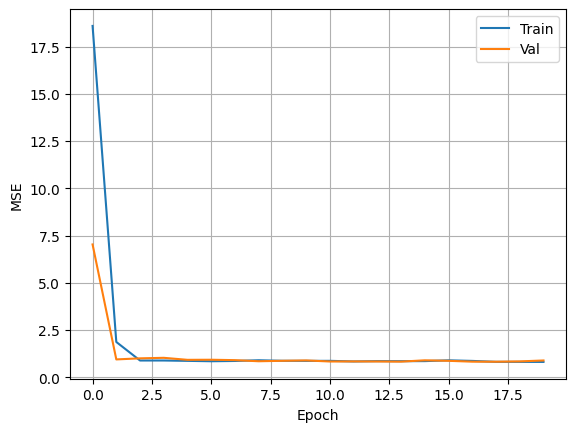

In [12]:
plt.plot(train_loss,label="Train")
plt.plot(val_loss,label="Val")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(); plt.show()


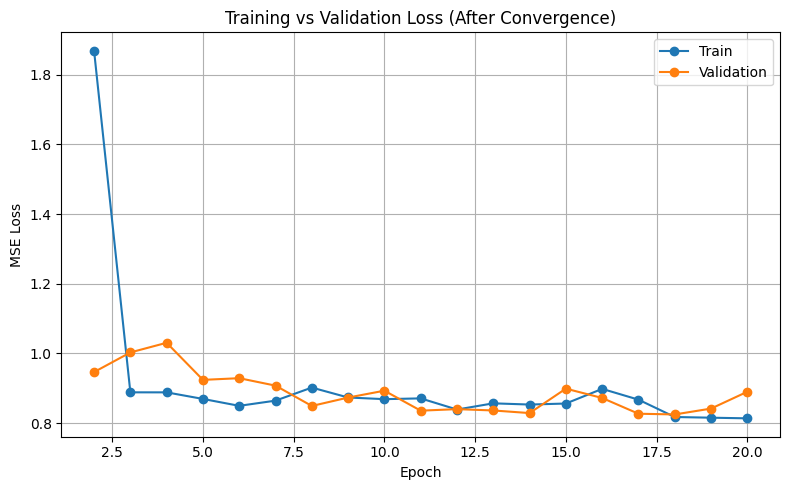

In [18]:
epochs = list(range(2, len(train_loss) + 1))

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss[1:], marker='o', label="Train")
plt.plot(epochs, val_loss[1:], marker='o', label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss (After Convergence)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
MODEL_PATH = "/content/drive/MyDrive/ed-dptnetVA_model.pt"
torch.save(model.state_dict(), MODEL_PATH)
print("✅ Model saved at:", MODEL_PATH)


✅ Model saved at: /content/drive/MyDrive/ed-dptnetVA_model.pt


In [14]:
MODEL_PATH = "/content/drive/MyDrive/ed-dptnetVA_model.pt"

model = ED_DPTNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [15]:
with torch.no_grad():
    dummy_A = torch.randn(1, 129, 2000).to(device)
    dummy_V = torch.randn(1, 140, 2000).to(device)
    out = model(dummy_A, dummy_V)

print("Output shape:", out.shape)  # should be [1, 2]


Output shape: torch.Size([1, 2])


In [16]:
def predict_valence_arousal(
    mp3_path,
    model,
    device,
    sr=22050,
    duration=45
):
    # ---------- Load audio ----------
    y, sr = librosa.load(mp3_path, sr=sr, duration=duration)

    # ---------- Feature extraction (SAME AS TRAINING) ----------
    y_harm, _ = librosa.effects.hpss(y)

    # AROUSAL FEATURES
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=128, hop_length=512
        )
    )
    rms = librosa.feature.rms(y=y, hop_length=512)[0]
    rms = np.interp(
        np.linspace(0, len(rms), mel.shape[1]),
        np.arange(len(rms)),
        rms
    ).reshape(1, -1)
    A = fix_length(np.vstack([mel, rms]))

    # VALENCE FEATURES
    mel_h = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=y_harm, sr=sr, n_mels=128, hop_length=512
        )
    )
    chroma = librosa.feature.chroma_stft(
        y=y_harm, sr=sr, hop_length=512
    )
    chroma = np.vstack([
        np.interp(
            np.linspace(0, chroma.shape[1], mel_h.shape[1]),
            np.arange(chroma.shape[1]),
            chroma[i]
        )
        for i in range(12)
    ])
    V = fix_length(np.vstack([mel_h, chroma]))

    # ---------- Torch tensors ----------
    A = torch.tensor(A, dtype=torch.float32).unsqueeze(0).to(device)
    V = torch.tensor(V, dtype=torch.float32).unsqueeze(0).to(device)

    # ---------- Inference ----------
    model.eval()
    with torch.no_grad():
        pred = model(A, V).cpu().numpy()[0]

    valence, arousal = float(pred[0]), float(pred[1])

    print(f"🎵 Song: {os.path.basename(mp3_path)}")
    print(f"👉 Valence : {valence:.2f}")
    print(f"👉 Arousal : {arousal:.2f}")

    return valence, arousal


In [17]:
mp3_file = "/content/ello adu ello.mp3"

predict_valence_arousal(
    mp3_file,
    model,
    device
)


🎵 Song: ello adu ello.mp3
👉 Valence : 6.07
👉 Arousal : 6.07


(6.069584846496582, 6.070261478424072)

In [20]:
MODEL_PATH = "/content/drive/MyDrive/ed-dptnet_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),  # optional
    "epoch": len(train_loss),
}, MODEL_PATH)

print("✅ Model saved to:", MODEL_PATH)


✅ Model saved to: /content/drive/MyDrive/ed-dptnet_model.pth
